In [1]:
# ============================================================
# ADABOOST - EMPLOYEE ATTRITION PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
import kagglehub
path = kagglehub.dataset_download("saurabhbadole/hr-employee-attrition")

Using Colab cache for faster access to the 'hr-employee-attrition' dataset.


In [16]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/hr-employee-attrition/HR-Employee-Attrition.csv


In [17]:
# ============================================================
# LOAD DATASET
# ============================================================

import pandas as pd

file_path = "/root/.cache/kagglehub/datasets/saurabhbadole/hr-employee-attrition/versions/1/HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [18]:
# ============================================================
# DATA UNDERSTANDING
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 5 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Missing Values:
0

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel       

In [19]:
# ============================================================
# TARGET VARIABLE - ATTRITION
# ============================================================

print("Employee Attrition Distribution:")
print(df["Attrition"].value_counts())

print("\nAttrition Percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

Employee Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


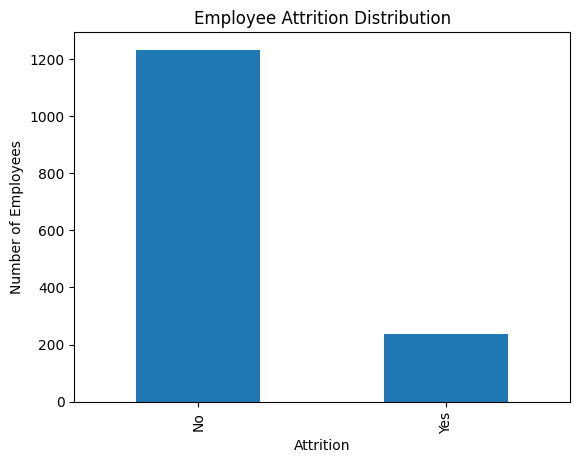

In [20]:
# ============================================================
# ATTRITION VISUALIZATION
# ============================================================

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [21]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

data = df.copy()

# Remove columns that do not provide useful predictive information
columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

data.drop(columns=columns_to_drop, inplace=True)

# Convert target variable: Yes = 1, No = 0
data["Attrition"] = data["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# Convert categorical variables into numerical dummy variables
data = pd.get_dummies(
    data,
    drop_first=True
)

print("Preprocessing completed!")
print("Processed dataset shape:", data.shape)

data.head()

Preprocessing completed!
Processed dataset shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [22]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

X = data.drop("Attrition", axis=1)
y = data["Attrition"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (1470, 44)
Target shape: (1470,)

Target values:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [23]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 44)
Testing data: (294, 44)


In [24]:
# ============================================================
# BUILD ADABOOST MODEL
# ============================================================

base_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("AdaBoost model created successfully!")

AdaBoost model created successfully!


In [25]:
# ============================================================
# TRAIN ADABOOST MODEL
# ============================================================

ada_model.fit(X_train, y_train)

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [26]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred = ada_model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ADABOOST MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

ADABOOST MODEL PERFORMANCE
Accuracy : 0.8435
Precision: 0.6667
Recall   : 0.0426
F1 Score : 0.0800


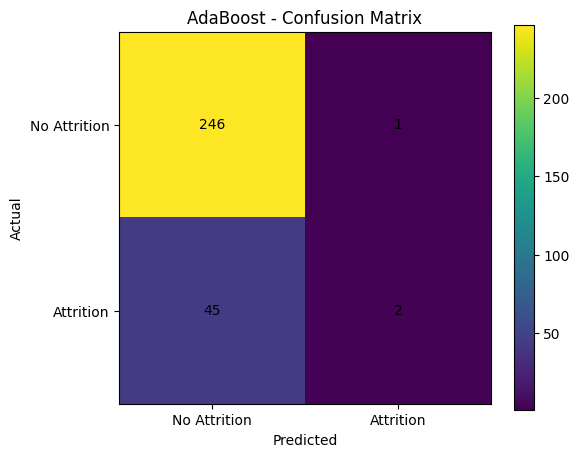

[[246   1]
 [ 45   2]]


In [28]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("AdaBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Attrition", "Attrition"])
plt.yticks([0, 1], ["No Attrition", "Attrition"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

print(cm)

Top 10 Important Features:
OverTime_Yes                 0.282799
TotalWorkingYears            0.131459
MonthlyIncome                0.120307
StockOptionLevel             0.106031
YearsWithCurrManager         0.056091
EnvironmentSatisfaction      0.048660
Age                          0.045164
JobInvolvement               0.032315
JobRole_Research Director    0.030909
NumCompaniesWorked           0.029731
dtype: float64


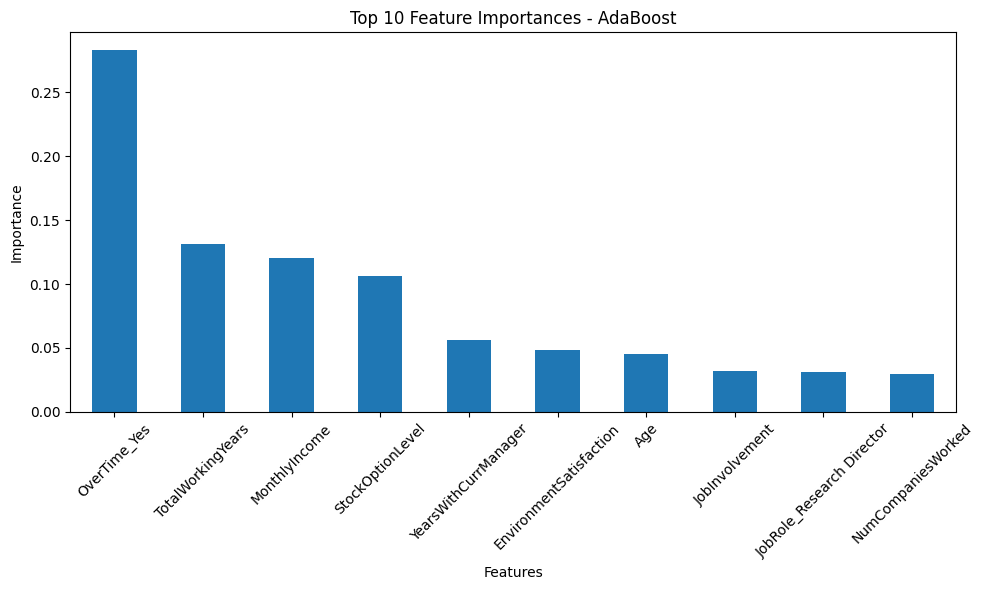

In [29]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    ada_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances - AdaBoost")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# NEW EMPLOYEE PREDICTION
# ============================================================

new_employee = X_test.iloc[[0]]

prediction = ada_model.predict(new_employee)[0]
probability = ada_model.predict_proba(new_employee)[0]

print("NEW EMPLOYEE PREDICTION")
print("=" * 40)

if prediction == 1:
    print("Prediction: Employee may leave the company")
else:
    print("Prediction: Employee may stay with the company")

print(f"Probability of Staying: {probability[0]:.2%}")
print(f"Probability of Attrition: {probability[1]:.2%}")

NEW EMPLOYEE PREDICTION
Prediction: Employee may stay with the company
Probability of Staying: 61.91%
Probability of Attrition: 38.09%


In [31]:
# ============================================================
# SAVE ADABOOST MODEL
# ============================================================

import joblib

joblib.dump(ada_model, "adaboost_employee_attrition_model.pkl")

print("AdaBoost model saved successfully!")

AdaBoost model saved successfully!


In [32]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("""
============================================================
FINAL CONCLUSION
============================================================

This project developed an AdaBoost classification model to
predict employee attrition.

The IBM HR Employee Attrition dataset was explored and
preprocessed before training the model. Categorical variables
were converted into numerical features and the data was
divided into training and testing sets.

AdaBoost was used as an ensemble learning algorithm to build
the employee attrition prediction model.

The model was evaluated using Accuracy, Precision, Recall,
F1 Score, and a Confusion Matrix. Feature importance was also
examined to identify the features contributing to the model's
predictions.

Finally, the trained model was used to predict whether an
employee may leave or stay with the organization.

This project demonstrates the application of AdaBoost for a
supervised classification problem and introduces ensemble
learning for employee attrition prediction.

============================================================
PROJECT 6 COMPLETE
============================================================
""")


FINAL CONCLUSION

This project developed an AdaBoost classification model to
predict employee attrition.

The IBM HR Employee Attrition dataset was explored and
preprocessed before training the model. Categorical variables
were converted into numerical features and the data was
divided into training and testing sets.

AdaBoost was used as an ensemble learning algorithm to build
the employee attrition prediction model.

The model was evaluated using Accuracy, Precision, Recall,
F1 Score, and a Confusion Matrix. Feature importance was also
examined to identify the features contributing to the model's
predictions.

Finally, the trained model was used to predict whether an
employee may leave or stay with the organization.

This project demonstrates the application of AdaBoost for a
supervised classification problem and introduces ensemble
learning for employee attrition prediction.

PROJECT 6 COMPLETE





Final Conclusion — Points
AdaBoost was used to predict employee attrition as a supervised classification problem.
The IBM HR Employee Attrition dataset was explored and preprocessed.
Categorical variables were converted into numerical features.
The dataset was divided into training and testing sets.
An AdaBoost Classifier was trained using decision-tree weak learners.
Model performance was evaluated using Accuracy, Precision, Recall, and F1 Score.
A confusion matrix was used to analyze prediction results.
Feature importance was examined to understand which variables contributed to the predictions.
The trained model was used to make a new employee attrition prediction.
The project demonstrates the application of ensemble learning using AdaBoost for employee attrition prediction.

